# Project 1 - Building & Evaluating ML Algorithms

In this project, you will explore a dataset containing **music-related attributes** and build machine learning models for classification and regression tasks. This project requires you to:

1. Carry exploratory data analysis to gather knowledge from data
2. Apply data visualization techniques
3. Build transformation pipelines for data preprocessing and data cleaning
4. Select machine learning algorithms for regression and classification tasks
5. Design pipelines for hyperparameter tuning and model selection
6. Implement performance evaluation metrics and evaluate results
7. Report observations, propose business-centric solutions and propose mitigating strategies

You will select your **own classification and regression tasks** based on the dataset.

## Deliverables

As part of this project, you should deliver the following materials:

1. [**4-page IEEE-format paper**](https://www.ieee.org/conferences/publishing/templates.html). Write a paper with no more than 4 pages addressing the **``tasks``** posed below. When writing this report, consider a business-oriented person as your reader (e.g. your PhD advisor, your internship manager, etc.). Tell *the story* for each datasets' goal and propose solutions by addressing (at least) the **``tasks posed below``**.

2. **Python Code**. Create two separate Notebooks: (1) "training.ipynb" used for training and hyperparameter tuning, (2) "test.ipynb" for evaluating the final trained model in the test set. The "test.ipynb" should load all trained objects and simply evaluate the performance. So don't forget to **push the trained models** to your repository to allow us to run it.

All of your code should run without any errors and be well-documented. 

3. **README.md file**. Edit the readme.md file in your repository and how to use your code. If there are user-defined parameters, your readme.md file must clearly indicate so and demonstrate how to use your code.

This is an **individual assignment**. 

These deliverables are **due Monday, March 3 @ 11:59pm**. Late submissions will not be accepted, so please plan accordingly.

---

# About the Dataset

This dataset contains attributes of songs played on Spotify until 2022, including their duration and various musical characteristics. It provides an opportunity to analyze how different song features relate to playtime and genre classification. The  dataset is available in the ```Spotify_Song_Attributes.csv``` file.

### Attribute Description


1. **trackName** - The name of the track.  
2. **artistName** - The name of the artist or band associated with the track.  
3. **msPlayed** - The duration in milliseconds that the track was played.  
4. **genre** - The genre or genres associated with the track.  
5. **danceability** - A measure of how suitable a track is for dancing.  
6. **energy** - The energy level of the track.  
7. **key** - The key of the track (e.g., C, D, E).  
8. **loudness** - The overall loudness of the track in decibels (dB).  
9. **mode** - The modality of the track (1 = major, 0 = minor).  
10. **speechiness** - The presence of spoken words in the track.  
11. **acousticness** - The acousticness of the track.  
12. **instrumentalness** - The probability of the track being instrumental.  
13. **liveness** - A measure of the presence of a live audience in the track.  
14. **valence** - The musical positiveness or happiness conveyed by the track.  
15. **tempo** - The tempo of the track in beats per minute (BPM).  
16. **type** - The type of the Spotify track.  
17. **id** - The unique identifier of the track.  
18. **uri** - The Spotify URI for the track.  
19. **track_href** - A link to the Spotify Web API endpoint for the track.  
20. **analysis_url** - A link to the audio analysis of the track.  
21. **duration_ms** - The duration of the track in milliseconds.  
22. **time_signature** - The time signature of the track.

---

# Assignment

In [1]:
from sklearn.model_selection import train_test_split, KFold
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline  
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet, LogisticRegression
from sklearn.preprocessing import MinMaxScaler, StandardScaler,RobustScaler,OneHotEncoder, OrdinalEncoder,label_binarize
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error,accuracy_score, classification_report, confusion_matrix,roc_curve, auc
from sklearn.ensemble import RandomForestClassifier

import seaborn as sns
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
plt.style.use('bmh')


from joblib import dump

## **Step 1: Exploratory Data Analysis (EDA)**  

### **What to Do**  
- Load the dataset and inspect its structure using `.head()`, `.info()`, `.describe()`.  
- Check for missing values and determine how to handle them (drop, impute, etc.).  
- Identify duplicates and remove them if necessary.  
- Analyze basic statistics of numerical features:  
  - Mean, median, standard deviation, min, max.  
  - Correlations between variables.  
- Check the distribution of key features using:  
  - Histograms  
  - Box plots   
  - others
- Analyze relationships between features using:  
  - Correlation heatmaps  
  - Scatter plots for key relationships  
  - If applicable, analyze categorical features (e.g., genre) using bar charts.
  - others
- Check for potential outliers and determine how to handle them.  

**``Task 1. Provide a summary of findings from EDA (bullet points or short analysis).``**

**``Task 2. Provide at least three visualizations showing trends or insights from the dataset.``**  

---



Task 1. Provide a summary of findings from EDA (bullet points or short analysis)

 Genre has the most null in the dataset,loudness have most outliers, and the tempo have the biggest range, but tempo (I guess) might not be a important varible, because compairing with the others,  correlation of tempo is near 0 to all other varible, so I'll keep it raw without any manipulate. 

Task 2. Provide at least three visualizations showing trends or insights from the dataset. 

I provide correlation heatmap, scatter plot to observe Danceability and Loudness and I also use boxplot to find the outliers

In [2]:
df = pd.read_csv("Spotify_Song_Attributes.csv")
print( df.info(),df.describe())
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10080 entries, 0 to 10079
Data columns (total 22 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   trackName         10080 non-null  object 
 1   artistName        10080 non-null  object 
 2   msPlayed          10080 non-null  int64  
 3   genre             8580 non-null   object 
 4   danceability      9530 non-null   float64
 5   energy            9530 non-null   float64
 6   key               9530 non-null   float64
 7   loudness          9530 non-null   float64
 8   mode              9530 non-null   float64
 9   speechiness       9530 non-null   float64
 10  acousticness      9530 non-null   float64
 11  instrumentalness  9530 non-null   float64
 12  liveness          9530 non-null   float64
 13  valence           9530 non-null   float64
 14  tempo             9530 non-null   float64
 15  type              9530 non-null   object 
 16  id                9530 non-null   object

,trackName,artistName,msPlayed,genre,danceability,energy,key,loudness,mode,speechiness,...,liveness,valence,tempo,type,id,uri,track_href,analysis_url,duration_ms,time_signature
0,"""Honest""",Nico Collins,191772,NaN,0.476,0.799,4.0,-4.939,0.0,0.2120,...,0.2570,0.577,162.139,audio_features,7dTxqsaFGHOXwtzHINjfHv,spotify:track:7dTxqsaFGHOXwtzHINjfHv,https://api.spotify.com/v1/tracks/7dTxqsaFGHOX...,https://api.spotify.com/v1/audio-analysis/7dTx...,191948.0,4.0
1,"""In The Hall Of The Mountain King"" from Peer G...",London Symphony Orchestra,1806234,british orchestra,0.475,0.130,7.0,-17.719,1.0,0.0510,...,0.1010,0.122,112.241,audio_features,14Qcrx6Dfjvcj0H8oV8oUW,spotify:track:14Qcrx6Dfjvcj0H8oV8oUW,https://api.spotify.com/v1/tracks/14Qcrx6Dfjvc...,https://api.spotify.com/v1/audio-analysis/14Qc...,150827.0,4.0
2,#BrooklynBloodPop!,SyKo,145610,glitchcore,0.691,0.814,1.0,-3.788,0.0,0.1170,...,0.3660,0.509,132.012,audio_features,7K9Z3yFNNLv5kwTjQYGjnu,spotify:track:7K9Z3yFNNLv5kwTjQYGjnu,https://api.spotify.com/v1/tracks/7K9Z3yFNNLv5...,https://api.spotify.com/v1/audio-analysis/7K9Z...,145611.0,4.0
3,$10,Good Morning,25058,experimental pop,0.624,0.596,4.0,-9.804,1.0,0.0314,...,0.1190,0.896,120.969,audio_features,3koAwrM1RO0TGMeQJ3qt9J,spotify:track:3koAwrM1RO0TGMeQJ3qt9J,https://api.spotify.com/v1/tracks/3koAwrM1RO0T...,https://api.spotify.com/v1/audio-analysis/3koA...,89509.0,4.0
4,(I Just) Died In Your Arms,Cutting Crew,5504949,album rock,0.625,0.726,11.0,-11.402,0.0,0.0444,...,0.0625,0.507,124.945,audio_features,4ByEFOBuLXpCqvO1kw8Wdm,spotify:track:4ByEFOBuLXpCqvO1kw8Wdm,https://api.spotify.com/v1/tracks/4ByEFOBuLXpC...,https://api.spotify.com/v1/audio-analysis/4ByE...,280400.0,4.0


In [3]:
numeric = ['danceability', 'energy', 'key', 'loudness', 'mode', 
            'speechiness', 'acousticness', 'instrumentalness', 
            'liveness', 'valence', 'tempo','time_signature']

df[numeric].corr()

,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
danceability,1.000000,0.277729,0.020130,0.325836,-0.046042,0.180340,-0.261199,-0.229848,0.006503,0.484760,0.009501,0.220027
energy,0.277729,1.000000,0.018073,0.797092,-0.063628,0.159274,-0.765161,-0.367535,0.192994,0.448547,0.194298,0.159684
key,0.020130,0.018073,1.000000,0.004905,-0.130183,0.000495,-0.004327,-0.005269,0.035003,0.047748,0.012974,0.027260
loudness,0.325836,0.797092,0.004905,1.000000,-0.004765,0.117273,-0.644611,-0.574075,0.135925,0.382998,0.172717,0.152307
mode,-0.046042,-0.063628,-0.130183,-0.004765,1.000000,-0.060533,0.066310,-0.049038,-0.028997,0.013050,0.009756,-0.031605
speechiness,0.180340,0.159274,0.000495,0.117273,-0.060533,1.000000,-0.104853,-0.107087,0.138333,0.131875,0.110031,0.025669
acousticness,-0.261199,-0.765161,-0.004327,-0.644611,0.066310,-0.104853,1.000000,0.322443,-0.129970,-0.305580,-0.169778,-0.159009
instrumentalness,-0.229848,-0.367535,-0.005269,-0.574075,-0.049038,-0.107087,0.322443,1.000000,-0.055113,-0.308459,-0.097843,-0.076233
liveness,0.006503,0.192994,0.035003,0.135925,-0.028997,0.138333,-0.129970,-0.055113,1.000000,0.076991,0.013823,0.006476
valence,0.484760,0.448547,0.047748,0.382998,0.013050,0.131875,-0.305580,-0.308459,0.076991,1.000000,0.110969,0.136320


In [4]:
non_num = df.columns.drop(df[numeric])
non_num

Index(['trackName', 'artistName', 'msPlayed', 'genre', 'type', 'id', 'uri',
       'track_href', 'analysis_url', 'duration_ms'],
      dtype='object')

In [5]:
corr_matrix = df[numeric].corr()
for col in numeric:
    total_abs_corr = corr_matrix[col].abs().sum() - 1 
    print(f"{col}: {total_abs_corr:.2f}")

danceability: 2.06
energy: 3.44
key: 0.31
loudness: 3.31
mode: 0.50
speechiness: 1.14
acousticness: 2.93
instrumentalness: 2.19
liveness: 0.82
valence: 2.45
tempo: 0.92
time_signature: 1.02


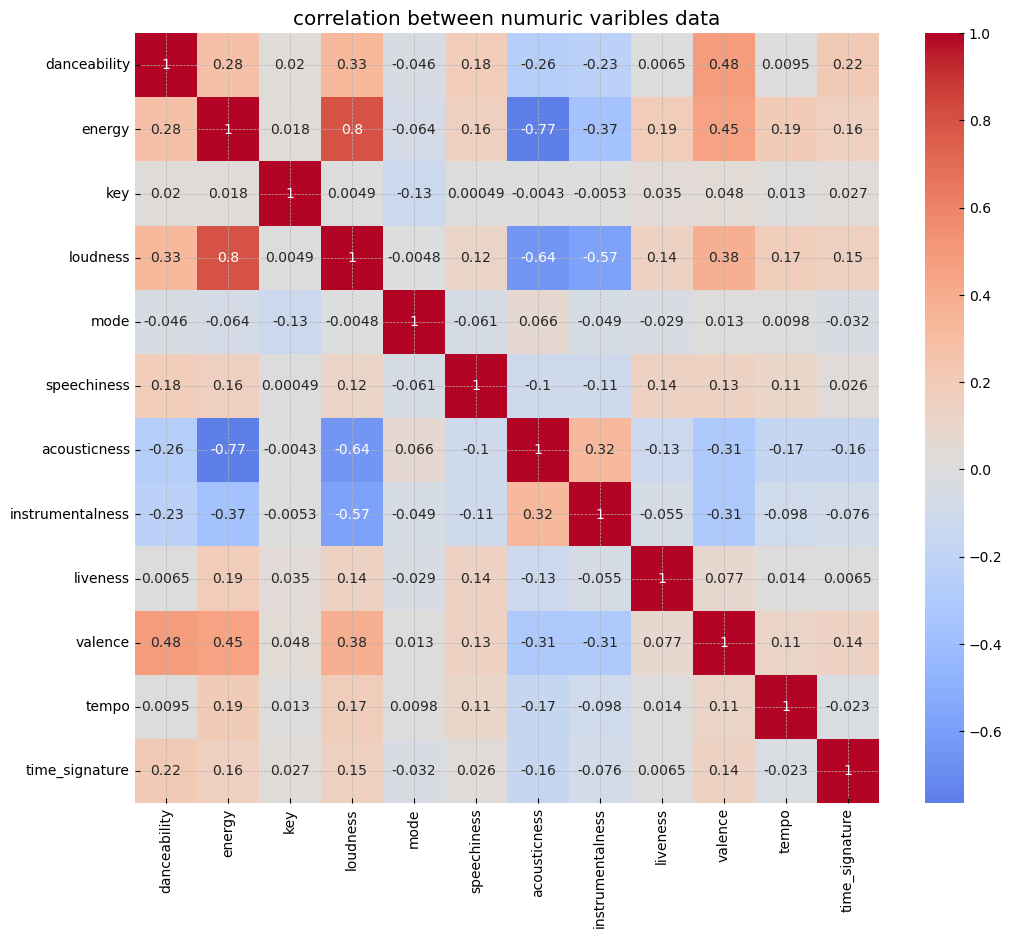

In [ ]:
plt.figure(figsize=(12, 10))
sns.heatmap(df[numeric].corr(), annot=True, cmap='coolwarm', center=0)
plt.title('correlation between numuric varibles data')
plt.show()

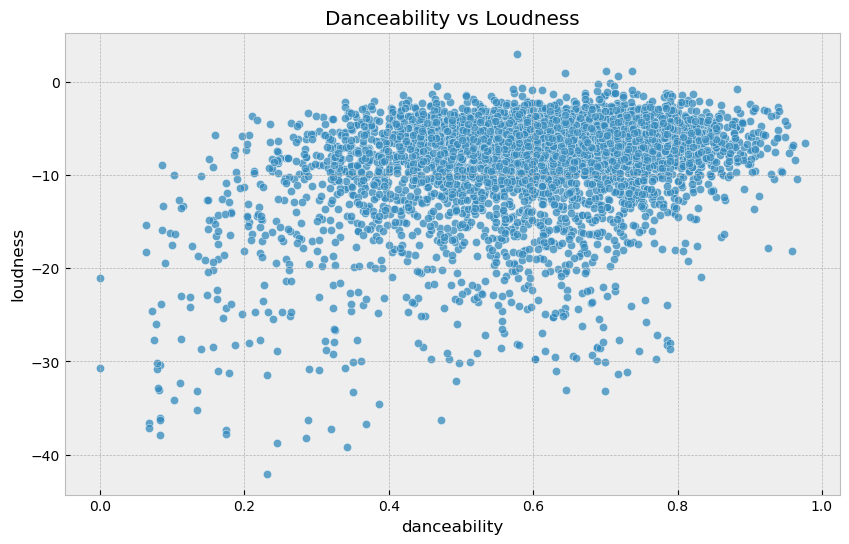

In [7]:
plt.figure(figsize=(10, 6))
sns.scatterplot(df, x='danceability', y='loudness', alpha=0.5)
plt.title('Danceability vs Loudness')
plt.show()

C:\Users\champ\AppData\Local\Temp\ipykernel_3276\3774321988.py:2: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([df[col].dropna() for col in df[numeric]],


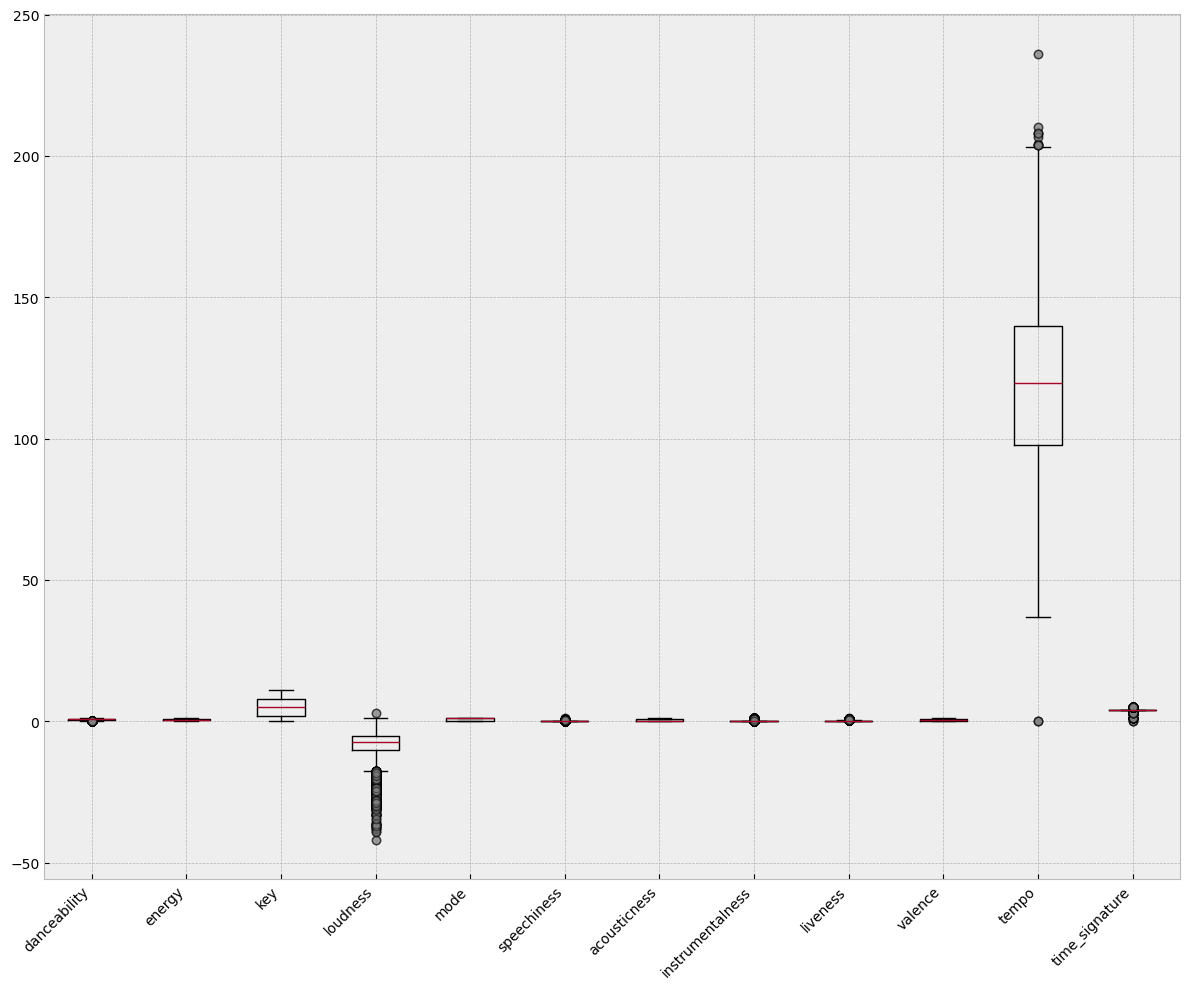

In [8]:
plt.figure(figsize=(12, 10))
plt.boxplot([df[col].dropna() for col in df[numeric]], 
            labels=numeric,
            flierprops={'marker': 'o', 'markerfacecolor': 'gray', 'alpha': 0.5})
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

## **Step 2: Data Preprocessing & Cleaning Pipelines**  

### **What to Do**  
- Handle missing values (e.g., drop rows, impute with mean/median).  
- Normalize or standardize numerical features if necessary.  
- Encode categorical variables (if applicable).  
- Remove outliers if they affect model performance.  
- Split the dataset into training (80%) and testing (20%) sets.  
- Store preprocessing steps in a pipeline for reuse.  

**``Task 3. Provide a written summary of the preprocessing steps.``**  

----


Task 3. Provide a written summary of the preprocessing steps.

At first,  we knows that the column 'genre' have the most missing value, so after we generate a new dataset that all the genre are non-null, we accidently get a dataset that have no missing values

In [9]:
df_clean = df[df['genre'].notna()].copy()
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8580 entries, 1 to 10079
Data columns (total 22 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   trackName         8580 non-null   object 
 1   artistName        8580 non-null   object 
 2   msPlayed          8580 non-null   int64  
 3   genre             8580 non-null   object 
 4   danceability      8580 non-null   float64
 5   energy            8580 non-null   float64
 6   key               8580 non-null   float64
 7   loudness          8580 non-null   float64
 8   mode              8580 non-null   float64
 9   speechiness       8580 non-null   float64
 10  acousticness      8580 non-null   float64
 11  instrumentalness  8580 non-null   float64
 12  liveness          8580 non-null   float64
 13  valence           8580 non-null   float64
 14  tempo             8580 non-null   float64
 15  type              8580 non-null   object 
 16  id                8580 non-null   object 
 17 

In [10]:
cat= ['genre']

In [11]:
num_pipeline = Pipeline([
    ('std_scaler', MinMaxScaler())
])

In [12]:
preprocessing = ColumnTransformer(
    transformers=[
        ('num', num_pipeline, numeric),
        ('cat', OneHotEncoder(sparse_output=False, 
                            handle_unknown='ignore'), 
        cat)
    ])
preprocessing

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('std_scaler',
                                                  MinMaxScaler())]),
                                 ['danceability', 'energy', 'key', 'loudness',
                                  'mode', 'speechiness', 'acousticness',
                                  'instrumentalness', 'liveness', 'valence',
                                  'tempo', 'time_signature']),
                                ('cat',
                                 OneHotEncoder(handle_unknown='ignore',
                                               sparse_output=False),
                                 ['genre'])])

C:\Users\champ\AppData\Local\Temp\ipykernel_3276\3025060969.py:2: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([df_clean[col].dropna() for col in df_clean[numeric]],


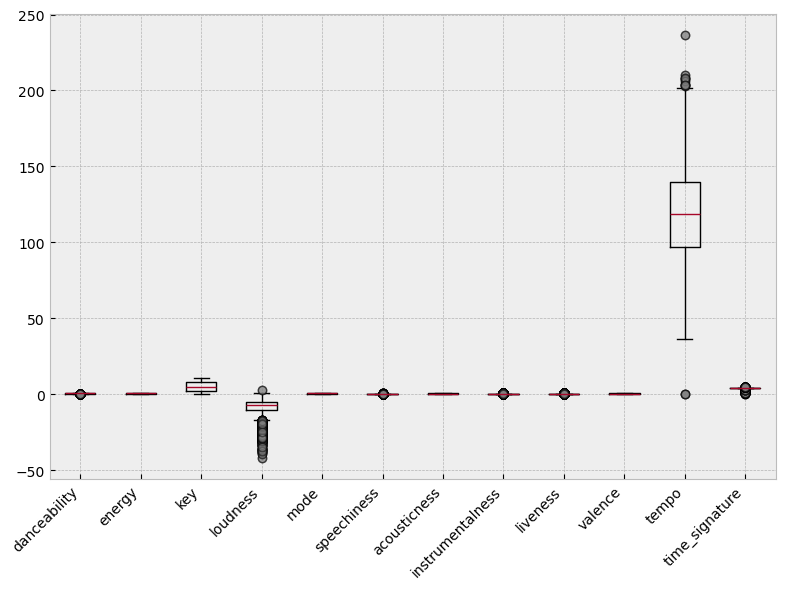

In [13]:
plt.figure(figsize=(8, 6))
plt.boxplot([df_clean[col].dropna() for col in df_clean[numeric]], 
            labels=numeric,
            flierprops={'marker': 'o', 'markerfacecolor': 'gray', 'alpha': 0.5})
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

In [14]:
len(df_clean['genre'].value_counts())

523

In [15]:
train_set, test_set = train_test_split( df_clean, test_size=0.2,  shuffle=True,  random_state=2025)
train_prepared = preprocessing.fit_transform(train_set)
test_prepared = preprocessing.transform(test_set)
train_prepared.shape,test_prepared.shape

((6864, 534), (1716, 534))

## **Step 3: Select a Classification and Regression Task**  

 
- Pick **one classification problem** (e.g., predict high/low `danceability`, predict a song’s `energy` category, etc.).  
- Pick **one regression problem** (e.g., predict a song’s `tempo` based on features, predict `loudness` based on other audio properties, etc.).  

**``Task 4. Clearly state the target variable for both classification and regression AND Explain why this task is interesting.``**  

---

**Task 4. Clearly state the target variable for both classification and regression AND Explain why this task is interesting.**

Regression : I'm going to use `loudness`, `acousticness` and `tempo` to predict `energy`, by the correlation heatmap, we can know that both `loudness` and `acousticness` have very high value with `energy`, and I asume `tempo` is very important to `energy`.

Classification: use `energy`, `tempo`	and `loudness` to predict `danceability`

## **Step 4: Training Machine Learning Models**  

### **Regression Task**  
- Train and compare:  
    - Linear Regression (with and without regularization, e.g., Ridge/Lasso)  
    - Decision Tree Regressor  

- Tune hyperparameters to optimize model performance using `GridSearchCV` or `RandomizedSearchCV`.    

- Compare models using:  
    - R² (Coefficient of Determination)  
    - Mean Absolute Error (MAE)  
    - Mean Squared Error (MSE)  
    - Root Mean Squared Error (RMSE)

- Save trained models using joblib
- Save the preprocessing pipeline (scalers, encoders, etc.)

In [16]:
df_reg= df_clean[['loudness','acousticness', 'tempo','energy']]
df_reg

,loudness,acousticness,tempo,energy
1,-17.719,0.9160,112.241,0.130
2,-3.788,0.0164,132.012,0.814
3,-9.804,0.4750,120.969,0.596
4,-11.402,0.0158,124.945,0.726
5,-5.925,0.2900,157.475,0.611
...,...,...,...,...
10074,-7.706,0.2020,136.055,0.477
10075,-16.992,0.9610,131.118,0.143
10077,-7.783,0.4380,65.152,0.158
10078,-14.025,0.9320,129.642,0.284


In [17]:
df_reg_train, df_reg_test = train_test_split(df_reg,
                                             train_size=0.8,
                                             random_state=2025,
                                             shuffle=True)
df_reg_test.shape,df_reg_train.shape

((1716, 4), (6864, 4))

In [18]:
df_reg_x_test = df_reg_test.drop(labels='energy', axis=1)
df_reg_x_train = df_reg_train.drop(labels='energy', axis=1)
df_reg_y_test = df_reg_test['energy'].copy()
df_reg_y_train = df_reg_train['energy'].copy()


#### linear regression

In [19]:
Model_0 = Pipeline([('LIN_reg',LinearRegression())])
Model_0.get_params()


{'memory': None,
 'steps': [('LIN_reg', LinearRegression())],
 'verbose': False,
 'LIN_reg': LinearRegression(),
 'LIN_reg__copy_X': True,
 'LIN_reg__fit_intercept': True,
 'LIN_reg__n_jobs': None,
 'LIN_reg__positive': False}

In [20]:
param_grid_0 = {
    'verbose': [True, False]
}

In [21]:
grid_search_0 = GridSearchCV(Model_0,
                          param_grid=param_grid_0,
                          cv=KFold(5, shuffle=True, random_state=0),
                          scoring='neg_mean_squared_error',
                          refit=True)

In [22]:
grid_search_0.fit(df_reg_x_train, df_reg_y_train)

[Pipeline] ........... (step 1 of 1) Processing LIN_reg, total=   0.0s
[Pipeline] ........... (step 1 of 1) Processing LIN_reg, total=   0.0s
[Pipeline] ........... (step 1 of 1) Processing LIN_reg, total=   0.0s
[Pipeline] ........... (step 1 of 1) Processing LIN_reg, total=   0.0s
[Pipeline] ........... (step 1 of 1) Processing LIN_reg, total=   0.0s
[Pipeline] ........... (step 1 of 1) Processing LIN_reg, total=   0.0s


GridSearchCV(cv=KFold(n_splits=5, random_state=0, shuffle=True),
             estimator=Pipeline(steps=[('LIN_reg', LinearRegression())]),
             param_grid={'verbose': [True, False]},
             scoring='neg_mean_squared_error')

In [23]:
grid_search_0.best_params_

{'verbose': True}

In [24]:
FModel_0 = grid_search_0.best_estimator_

In [25]:
train0 = FModel_0.predict(df_reg_x_train)
test0 = FModel_0.predict(df_reg_x_test)

In [26]:
print('r2:', r2_score(df_reg_y_test, test0))
print('mae:', mean_absolute_error(df_reg_y_test, test0))
print('mse:', mean_squared_error(df_reg_y_test, test0))
print('RMSE: ', np.sqrt(mean_squared_error(df_reg_y_test, test0)))

r2: 0.733698078836291
mae: 0.1007881454412219
mse: 0.015839315820366705
RMSE:  0.12585434366904746


#### Ridge

In [27]:
Model_1 = Pipeline([('ridge_reg',Ridge())])
Model_1.get_params()

{'memory': None,
 'steps': [('ridge_reg', Ridge())],
 'verbose': False,
 'ridge_reg': Ridge(),
 'ridge_reg__alpha': 1.0,
 'ridge_reg__copy_X': True,
 'ridge_reg__fit_intercept': True,
 'ridge_reg__max_iter': None,
 'ridge_reg__positive': False,
 'ridge_reg__random_state': None,
 'ridge_reg__solver': 'auto',
 'ridge_reg__tol': 0.0001}

In [28]:
param_grid_1 = {
    'verbose': [True, False],
    'ridge_reg__alpha': [0, 0.001, 0.01, 0.1, 0.2, 0.5, 1]
}

In [29]:
grid_search_1 = GridSearchCV(Model_1,
                          param_grid=param_grid_1,
                          cv=KFold(5, shuffle=True, random_state=0),
                          scoring='neg_mean_squared_error',
                          refit=True)

In [30]:
grid_search_1

GridSearchCV(cv=KFold(n_splits=5, random_state=0, shuffle=True),
             estimator=Pipeline(steps=[('ridge_reg', Ridge())]),
             param_grid={'ridge_reg__alpha': [0, 0.001, 0.01, 0.1, 0.2, 0.5, 1],
                         'verbose': [True, False]},
             scoring='neg_mean_squared_error')

In [31]:
grid_search_1.fit(df_reg_x_train, df_reg_y_train)

[Pipeline] ......... (step 1 of 1) Processing ridge_reg, total=   0.0s
[Pipeline] ......... (step 1 of 1) Processing ridge_reg, total=   0.0s
[Pipeline] ......... (step 1 of 1) Processing ridge_reg, total=   0.0s
[Pipeline] ......... (step 1 of 1) Processing ridge_reg, total=   0.0s
[Pipeline] ......... (step 1 of 1) Processing ridge_reg, total=   0.0s
[Pipeline] ......... (step 1 of 1) Processing ridge_reg, total=   0.0s
[Pipeline] ......... (step 1 of 1) Processing ridge_reg, total=   0.0s
[Pipeline] ......... (step 1 of 1) Processing ridge_reg, total=   0.0s
[Pipeline] ......... (step 1 of 1) Processing ridge_reg, total=   0.0s
[Pipeline] ......... (step 1 of 1) Processing ridge_reg, total=   0.0s
[Pipeline] ......... (step 1 of 1) Processing ridge_reg, total=   0.0s
[Pipeline] ......... (step 1 of 1) Processing ridge_reg, total=   0.0s
[Pipeline] ......... (step 1 of 1) Processing ridge_reg, total=   0.0s
[Pipeline] ......... (step 1 of 1) Processing ridge_reg, total=   0.0s
[Pipel

GridSearchCV(cv=KFold(n_splits=5, random_state=0, shuffle=True),
             estimator=Pipeline(steps=[('ridge_reg', Ridge())]),
             param_grid={'ridge_reg__alpha': [0, 0.001, 0.01, 0.1, 0.2, 0.5, 1],
                         'verbose': [True, False]},
             scoring='neg_mean_squared_error')

In [32]:
grid_search_1.best_params_

{'ridge_reg__alpha': 0.1, 'verbose': True}

In [33]:
FModel_1 = grid_search_1.best_estimator_

In [34]:
train1 = FModel_1.predict(df_reg_x_train)
test1 = FModel_1.predict(df_reg_x_test)

In [35]:
print('r2:', r2_score(df_reg_y_test, test1))
print('mae:', mean_absolute_error(df_reg_y_test, test1))
print('mse:', mean_squared_error(df_reg_y_test, test1))
print('RMSE: ', np.sqrt(mean_squared_error(df_reg_y_test, test1)))


r2: 0.7336979992764392
mae: 0.10078882430007285
mse: 0.015839320552490356
RMSE:  0.12585436246904735


#### Lasso

In [36]:
Model_2 = Pipeline([('lasso_reg',Lasso())])
Model_2.get_params()

{'memory': None,
 'steps': [('lasso_reg', Lasso())],
 'verbose': False,
 'lasso_reg': Lasso(),
 'lasso_reg__alpha': 1.0,
 'lasso_reg__copy_X': True,
 'lasso_reg__fit_intercept': True,
 'lasso_reg__max_iter': 1000,
 'lasso_reg__positive': False,
 'lasso_reg__precompute': False,
 'lasso_reg__random_state': None,
 'lasso_reg__selection': 'cyclic',
 'lasso_reg__tol': 0.0001,
 'lasso_reg__warm_start': False}

In [37]:
param_grid_2 = {
    'verbose': [True, False],
    'lasso_reg__alpha': [0, 0.001, 0.01, 0.1, 0.2, 0.5, 1]
}

In [38]:
grid_search_2 = GridSearchCV(Model_2,
                          param_grid=param_grid_2,
                          cv=KFold(5, shuffle=True, random_state=0),
                          scoring='neg_mean_squared_error',
                          refit=True)

In [39]:
grid_search_2.fit(df_reg_x_train, df_reg_y_train)

[Pipeline] ......... (step 1 of 1) Processing lasso_reg, total=   0.1s
[Pipeline] ......... (step 1 of 1) Processing lasso_reg, total=   0.0s


c:\Users\champ\miniconda3\envs\aml\lib\site-packages\sklearn\base.py:1473: UserWarning: With alpha=0, this algorithm does not converge well. You are advised to use the LinearRegression estimator
  return fit_method(estimator, *args, **kwargs)
c:\Users\champ\miniconda3\envs\aml\lib\site-packages\sklearn\linear_model\_coordinate_descent.py:697: UserWarning: Coordinate descent with no regularization may lead to unexpected results and is discouraged.
  model = cd_fast.enet_coordinate_descent(
c:\Users\champ\miniconda3\envs\aml\lib\site-packages\sklearn\linear_model\_coordinate_descent.py:697: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.070e+01, tolerance: 3.174e-02 Linear regression models with null weight for the l1 regularization term are more efficiently fitted using one of the solvers implemented in sklearn.linear_model.Ridge/RidgeCV instead.
  

[Pipeline] ......... (step 1 of 1) Processing lasso_reg, total=   0.0s
[Pipeline] ......... (step 1 of 1) Processing lasso_reg, total=   0.0s
[Pipeline] ......... (step 1 of 1) Processing lasso_reg, total=   0.0s


c:\Users\champ\miniconda3\envs\aml\lib\site-packages\sklearn\base.py:1473: UserWarning: With alpha=0, this algorithm does not converge well. You are advised to use the LinearRegression estimator
  return fit_method(estimator, *args, **kwargs)
c:\Users\champ\miniconda3\envs\aml\lib\site-packages\sklearn\linear_model\_coordinate_descent.py:697: UserWarning: Coordinate descent with no regularization may lead to unexpected results and is discouraged.
  model = cd_fast.enet_coordinate_descent(
c:\Users\champ\miniconda3\envs\aml\lib\site-packages\sklearn\linear_model\_coordinate_descent.py:697: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.187e+01, tolerance: 3.177e-02 Linear regression models with null weight for the l1 regularization term are more efficiently fitted using one of the solvers implemented in sklearn.linear_model.Ridge/RidgeCV instead.
  

[Pipeline] ......... (step 1 of 1) Processing lasso_reg, total=   0.0s
[Pipeline] ......... (step 1 of 1) Processing lasso_reg, total=   0.0s
[Pipeline] ......... (step 1 of 1) Processing lasso_reg, total=   0.0s
[Pipeline] ......... (step 1 of 1) Processing lasso_reg, total=   0.0s
[Pipeline] ......... (step 1 of 1) Processing lasso_reg, total=   0.0s
[Pipeline] ......... (step 1 of 1) Processing lasso_reg, total=   0.0s
[Pipeline] ......... (step 1 of 1) Processing lasso_reg, total=   0.0s
[Pipeline] ......... (step 1 of 1) Processing lasso_reg, total=   0.0s
[Pipeline] ......... (step 1 of 1) Processing lasso_reg, total=   0.0s
[Pipeline] ......... (step 1 of 1) Processing lasso_reg, total=   0.0s
[Pipeline] ......... (step 1 of 1) Processing lasso_reg, total=   0.0s
[Pipeline] ......... (step 1 of 1) Processing lasso_reg, total=   0.0s
[Pipeline] ......... (step 1 of 1) Processing lasso_reg, total=   0.0s
[Pipeline] ......... (step 1 of 1) Processing lasso_reg, total=   0.0s
[Pipel

c:\Users\champ\miniconda3\envs\aml\lib\site-packages\sklearn\base.py:1473: UserWarning: With alpha=0, this algorithm does not converge well. You are advised to use the LinearRegression estimator
  return fit_method(estimator, *args, **kwargs)
c:\Users\champ\miniconda3\envs\aml\lib\site-packages\sklearn\linear_model\_coordinate_descent.py:697: UserWarning: Coordinate descent with no regularization may lead to unexpected results and is discouraged.
  model = cd_fast.enet_coordinate_descent(
c:\Users\champ\miniconda3\envs\aml\lib\site-packages\sklearn\linear_model\_coordinate_descent.py:697: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.149e+01, tolerance: 3.989e-02 Linear regression models with null weight for the l1 regularization term are more efficiently fitted using one of the solvers implemented in sklearn.linear_model.Ridge/RidgeCV instead.
  

GridSearchCV(cv=KFold(n_splits=5, random_state=0, shuffle=True),
             estimator=Pipeline(steps=[('lasso_reg', Lasso())]),
             param_grid={'lasso_reg__alpha': [0, 0.001, 0.01, 0.1, 0.2, 0.5, 1],
                         'verbose': [True, False]},
             scoring='neg_mean_squared_error')

In [40]:
grid_search_2.best_params_

{'lasso_reg__alpha': 0, 'verbose': True}

In [41]:
FModel_2 = grid_search_2.best_estimator_

In [42]:
train2 = FModel_2.predict(df_reg_x_train)
test2 = FModel_2.predict(df_reg_x_test)

In [43]:
print('r2:', r2_score(df_reg_y_test, test2))
print('mae:', mean_absolute_error(df_reg_y_test, test2))
print('mse:', mean_squared_error(df_reg_y_test, test2))
print('RMSE: ', np.sqrt(mean_squared_error(df_reg_y_test, test2)))

r2: 0.7336980788362911
mae: 0.1007881454412219
mse: 0.015839315820366694
RMSE:  0.1258543436690474


#### DecisionTreeRegressor

In [44]:
Model_3 = Pipeline([('dtree_reg',DecisionTreeRegressor())])
Model_3.get_params()

{'memory': None,
 'steps': [('dtree_reg', DecisionTreeRegressor())],
 'verbose': False,
 'dtree_reg': DecisionTreeRegressor(),
 'dtree_reg__ccp_alpha': 0.0,
 'dtree_reg__criterion': 'squared_error',
 'dtree_reg__max_depth': None,
 'dtree_reg__max_features': None,
 'dtree_reg__max_leaf_nodes': None,
 'dtree_reg__min_impurity_decrease': 0.0,
 'dtree_reg__min_samples_leaf': 1,
 'dtree_reg__min_samples_split': 2,
 'dtree_reg__min_weight_fraction_leaf': 0.0,
 'dtree_reg__monotonic_cst': None,
 'dtree_reg__random_state': None,
 'dtree_reg__splitter': 'best'}

In [45]:
param_grid_3 = {
    'dtree_reg__max_depth': [3, 6, 9, None],        
    'dtree_reg__min_samples_split': [2, 5, 10]      
}

In [46]:
grid_search_3 = GridSearchCV(Model_3,
                          param_grid=param_grid_3,
                          cv=KFold(5, shuffle=True, random_state=0),
                          scoring='neg_mean_squared_error',
                          refit=True)

In [47]:
grid_search_3.fit(df_reg_x_train, df_reg_y_train)

GridSearchCV(cv=KFold(n_splits=5, random_state=0, shuffle=True),
             estimator=Pipeline(steps=[('dtree_reg', DecisionTreeRegressor())]),
             param_grid={'dtree_reg__max_depth': [3, 6, 9, None],
                         'dtree_reg__min_samples_split': [2, 5, 10]},
             scoring='neg_mean_squared_error')

In [48]:
grid_search_3.best_params_

{'dtree_reg__max_depth': None, 'dtree_reg__min_samples_split': 2}

In [49]:
FModel_3 = grid_search_3.best_estimator_

In [50]:
train3 = FModel_3.predict(df_reg_x_train)
test3 = FModel_3.predict(df_reg_x_test)

In [51]:
print('r2:', r2_score(df_reg_y_test, test3))
print('mae:', mean_absolute_error(df_reg_y_test, test3))
print('mse:', mean_squared_error(df_reg_y_test, test3))
print('RMSE: ', np.sqrt(mean_squared_error(df_reg_y_test, test3)))

r2: 0.9267451460215685
mae: 0.021116958041958043
mse: 0.004357110014335665
RMSE:  0.06600840866386391


In [52]:
dump(FModel_0, 'model_linear_reg.joblib')
dump(FModel_1, 'model_Ridge.joblib')
dump(FModel_2, 'model_Lasso.joblib')
dump(FModel_3, 'model_DecisionTreeRegressor.joblib')

['model_DecisionTreeRegressor.joblib']

### **Classification Task**  
- Train and compare:  
    - Logistic Regression  
    - Random Forest Classifier  

- Tune hyperparameters using `GridSearchCV` or `RandomizedSearchCV`.  

- Measure performance using:  
    - Accuracy  
    - Precision, Recall, F1-score  
    - Confusion matrix  
    - ROC-AUC curve  

- Save trained models using joblib
- Save the preprocessing pipeline (scalers, encoders, etc.)

In [53]:
danceability_cat = pd.cut(df_clean['danceability'],
                         bins=[-1, 0.3, 0.6,11], 
                        labels=['low', 'medium', 'high'])

In [54]:
df_class= df_clean[['loudness','energy','tempo','danceability']]
df_class.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8580 entries, 1 to 10079
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   loudness      8580 non-null   float64
 1   energy        8580 non-null   float64
 2   tempo         8580 non-null   float64
 3   danceability  8580 non-null   float64
dtypes: float64(4)
memory usage: 335.2 KB


In [55]:
danceability_cat.info()

<class 'pandas.core.series.Series'>
Index: 8580 entries, 1 to 10079
Series name: danceability
Non-Null Count  Dtype   
--------------  -----   
8580 non-null   category
dtypes: category(1)
memory usage: 75.5 KB


In [56]:
train_set, test_set, danceability_cat_train, danceability_cat_test = train_test_split(
    df_class,  
    danceability_cat,
    test_size=0.2, 
    shuffle=True,  
    random_state=2025,  
    stratify=danceability_cat  )

In [57]:
df_class_y_train = danceability_cat_train
df_class_x_train = train_set.drop(labels='danceability', axis=1)
df_class_y_test = danceability_cat_test 
df_class_x_test = test_set.drop(labels='danceability', axis=1)

#### Logistic Regression  

In [58]:
Model_4 = Pipeline([('Log_reg',LogisticRegression())])
Model_4.get_params()

{'memory': None,
 'steps': [('Log_reg', LogisticRegression())],
 'verbose': False,
 'Log_reg': LogisticRegression(),
 'Log_reg__C': 1.0,
 'Log_reg__class_weight': None,
 'Log_reg__dual': False,
 'Log_reg__fit_intercept': True,
 'Log_reg__intercept_scaling': 1,
 'Log_reg__l1_ratio': None,
 'Log_reg__max_iter': 100,
 'Log_reg__multi_class': 'deprecated',
 'Log_reg__n_jobs': None,
 'Log_reg__penalty': 'l2',
 'Log_reg__random_state': None,
 'Log_reg__solver': 'lbfgs',
 'Log_reg__tol': 0.0001,
 'Log_reg__verbose': 0,
 'Log_reg__warm_start': False}

In [59]:
param_grid_4 = {
    'Log_reg__penalty': ['l2', None],  
    'Log_reg__C': [0.1, 1.0, 10.0]    }

In [60]:
grid_search_4 = GridSearchCV(Model_4,
                          param_grid=param_grid_4,
                          cv=KFold(5, shuffle=True, random_state=0),
                          scoring='neg_mean_squared_error',
                          refit=True)

In [61]:
grid_search_4.fit(df_class_x_train, df_class_y_train)

c:\Users\champ\miniconda3\envs\aml\lib\site-packages\sklearn\model_selection\_validation.py:982: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "c:\Users\champ\miniconda3\envs\aml\lib\site-packages\sklearn\model_selection\_validation.py", line 971, in _score
    scores = scorer(estimator, X_test, y_test, **score_params)
  File "c:\Users\champ\miniconda3\envs\aml\lib\site-packages\sklearn\metrics\_scorer.py", line 279, in __call__
    return self._score(partial(_cached_call, None), estimator, X, y_true, **_kwargs)
  File "c:\Users\champ\miniconda3\envs\aml\lib\site-packages\sklearn\metrics\_scorer.py", line 376, in _score
    return self._sign * self._score_func(y_true, y_pred, **scoring_kwargs)
  File "c:\Users\champ\miniconda3\envs\aml\lib\site-packages\sklearn\utils\_param_validation.py", line 213, in wrapper
    return func(*args, **kwargs)
  File "c:\Users\champ\minicon

GridSearchCV(cv=KFold(n_splits=5, random_state=0, shuffle=True),
             estimator=Pipeline(steps=[('Log_reg', LogisticRegression())]),
             param_grid={'Log_reg__C': [0.1, 1.0, 10.0],
                         'Log_reg__penalty': ['l2', None]},
             scoring='neg_mean_squared_error')

In [62]:
grid_search_4.best_params_


{'Log_reg__C': 0.1, 'Log_reg__penalty': 'l2'}

In [63]:
FModel_4 = grid_search_4.best_estimator_

In [64]:
train4 = FModel_4.predict(df_class_x_train)
test4= FModel_4.predict(df_class_x_test)

In [65]:
train_accuracy = accuracy_score(df_class_y_train, train4)
test_accuracy = accuracy_score(df_class_y_test, test4)
print(f"accuracy: {test_accuracy:.4f}")


accuracy: 0.5932


In [66]:
print("classification_report:")
print(classification_report(df_class_y_test, test4))

classification_report:
              precision    recall  f1-score   support

        high       0.61      0.90      0.73       957
         low       0.50      0.14      0.22        80
      medium       0.53      0.21      0.30       679

    accuracy                           0.59      1716
   macro avg       0.55      0.42      0.41      1716
weighted avg       0.57      0.59      0.53      1716



Text(0.5, 63.583333333333314, 'predicted label')

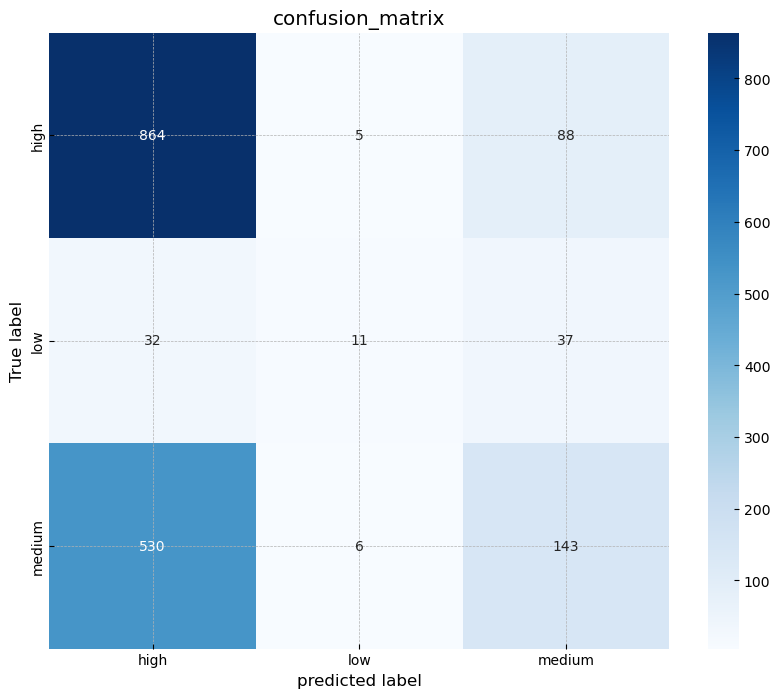

In [67]:
plt.figure(figsize=(10, 8))
cm = confusion_matrix(df_class_y_test, test4)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=np.unique(df_class_y_test),
            yticklabels=np.unique(df_class_y_test))

plt.title('confusion_matrix')
plt.ylabel('True label')
plt.xlabel('predicted label')

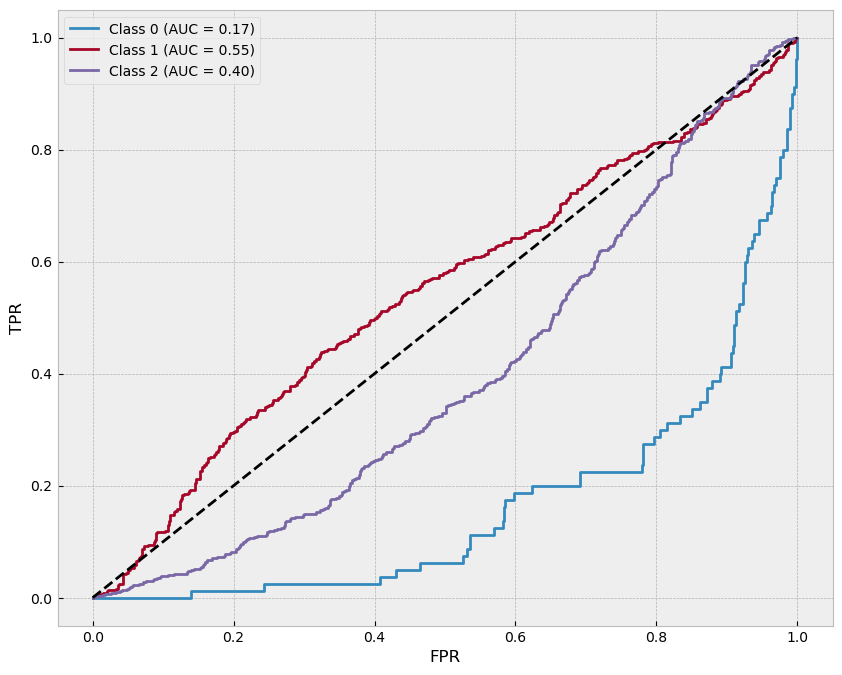

In [68]:
y_pred_proba = FModel_4.predict_proba(df_class_x_test)
y_test_bin = pd.get_dummies(df_class_y_test)
plt.figure(figsize=(10, 8))
for i in range(len(y_test_bin.columns)):
    fpr, tpr, _ = roc_curve(y_test_bin.iloc[:, i], y_pred_proba[:, i])
    auc_score = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'Class {i} (AUC = {auc_score:.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('FPR')
plt.ylabel('TPR')
plt.legend()
plt.show()

In [69]:
dump(FModel_4, 'model_LogisticRegression.joblib')

['model_LogisticRegression.joblib']

#### Random Forest Classifier

In [70]:
Model_5 = Pipeline([('RanFclass',RandomForestClassifier())])
Model_5.get_params()

{'memory': None,
 'steps': [('RanFclass', RandomForestClassifier())],
 'verbose': False,
 'RanFclass': RandomForestClassifier(),
 'RanFclass__bootstrap': True,
 'RanFclass__ccp_alpha': 0.0,
 'RanFclass__class_weight': None,
 'RanFclass__criterion': 'gini',
 'RanFclass__max_depth': None,
 'RanFclass__max_features': 'sqrt',
 'RanFclass__max_leaf_nodes': None,
 'RanFclass__max_samples': None,
 'RanFclass__min_impurity_decrease': 0.0,
 'RanFclass__min_samples_leaf': 1,
 'RanFclass__min_samples_split': 2,
 'RanFclass__min_weight_fraction_leaf': 0.0,
 'RanFclass__monotonic_cst': None,
 'RanFclass__n_estimators': 100,
 'RanFclass__n_jobs': None,
 'RanFclass__oob_score': False,
 'RanFclass__random_state': None,
 'RanFclass__verbose': 0,
 'RanFclass__warm_start': False}

In [71]:
param_grid_5 = {
    'RanFclass__n_estimators': [50, 100, 200],

    'RanFclass__max_depth': [3, 5, 7, None]
}

In [72]:
grid_search_5 = GridSearchCV(Model_5,
                          param_grid=param_grid_5,
                          cv=KFold(5, shuffle=True, random_state=0),
                          scoring='neg_mean_squared_error',
                          refit=True)

In [73]:
grid_search_5.fit(df_class_x_train, df_class_y_train)

c:\Users\champ\miniconda3\envs\aml\lib\site-packages\sklearn\model_selection\_validation.py:982: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "c:\Users\champ\miniconda3\envs\aml\lib\site-packages\sklearn\model_selection\_validation.py", line 971, in _score
    scores = scorer(estimator, X_test, y_test, **score_params)
  File "c:\Users\champ\miniconda3\envs\aml\lib\site-packages\sklearn\metrics\_scorer.py", line 279, in __call__
    return self._score(partial(_cached_call, None), estimator, X, y_true, **_kwargs)
  File "c:\Users\champ\miniconda3\envs\aml\lib\site-packages\sklearn\metrics\_scorer.py", line 376, in _score
    return self._sign * self._score_func(y_true, y_pred, **scoring_kwargs)
  File "c:\Users\champ\miniconda3\envs\aml\lib\site-packages\sklearn\utils\_param_validation.py", line 213, in wrapper
    return func(*args, **kwargs)
  File "c:\Users\champ\minicon

GridSearchCV(cv=KFold(n_splits=5, random_state=0, shuffle=True),
             estimator=Pipeline(steps=[('RanFclass',
                                        RandomForestClassifier())]),
             param_grid={'RanFclass__max_depth': [3, 5, 7, None],
                         'RanFclass__n_estimators': [50, 100, 200]},
             scoring='neg_mean_squared_error')

In [74]:
grid_search_5.best_params_

{'RanFclass__max_depth': 3, 'RanFclass__n_estimators': 50}

In [75]:
FModel_5 = grid_search_5.best_estimator_

In [76]:
train5 = FModel_5.predict(df_class_x_train)
test5= FModel_5.predict(df_class_x_test)

In [77]:
train_accuracy_dt = accuracy_score(df_class_y_train, train5)
test_accuracy_dt = accuracy_score(df_class_y_test, test5)
print(f"accuracy: {test_accuracy:.4f}")

accuracy: 0.5932


In [78]:
print("classification_report:")
print(classification_report(df_class_y_test, test5))

classification_report:
              precision    recall  f1-score   support

        high       0.65      0.84      0.73       957
         low       0.00      0.00      0.00        80
      medium       0.54      0.39      0.45       679

    accuracy                           0.62      1716
   macro avg       0.40      0.41      0.40      1716
weighted avg       0.58      0.62      0.59      1716



Text(0.5, 63.583333333333314, 'predicted label')

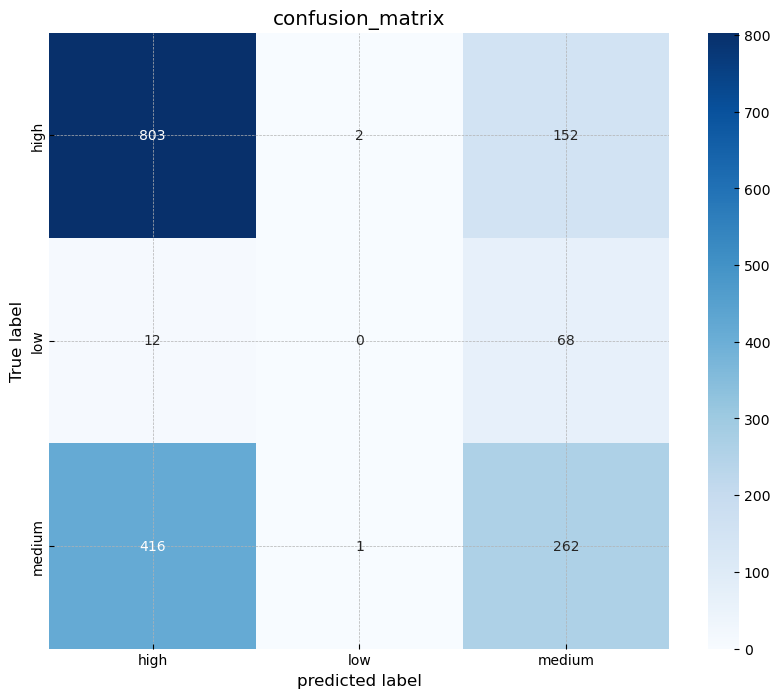

In [79]:
plt.figure(figsize=(10, 8))
cm = confusion_matrix(df_class_y_test, test5)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=np.unique(df_class_y_test),
            yticklabels=np.unique(df_class_y_test))

plt.title('confusion_matrix')
plt.ylabel('True label')
plt.xlabel('predicted label')

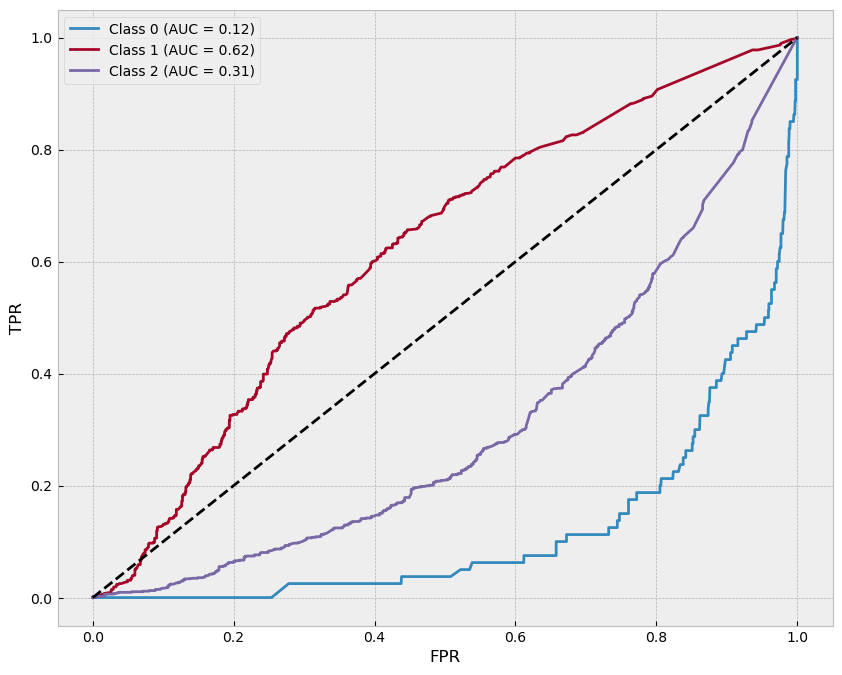

In [80]:
y_pred_proba = FModel_5.predict_proba(df_class_x_test)
y_test_bin = pd.get_dummies(df_class_y_test)
plt.figure(figsize=(10, 8))
for i in range(len(y_test_bin.columns)):
    fpr, tpr, _ = roc_curve(y_test_bin.iloc[:, i], y_pred_proba[:, i])
    auc_score = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'Class {i} (AUC = {auc_score:.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('FPR')
plt.ylabel('TPR')
plt.legend()
plt.show()

In [81]:
dump(FModel_5, 'RandomForestClassifier.joblib')

['RandomForestClassifier.joblib']

### ***``Task 5. After completing all steps above, provide the following:``***
- Training performance metrics for each model.  
- A short explanation of which model performed better and why.
- Are there any differences when adding regularization into regression? Which features are more important? 

---

1. A short explanation of which model performed better and why.

For the regression one, Decision Tree works better, because our feature set appears to have such non-linear patterns, making the Decision Tree naturally more suitable for this prediction task.

For the classification one, Random Forest Classifier performs well on our selected features as it combines multiple decision trees into an ensemble model, allowing it to capture complex patterns in the energy and loudness relationships while reducing overfitting through majority voting across trees.


2. Are there any differences when adding regularization into regression? Which features are more important? 

For my model, it didn't work so well, but for other topic, I think it might work better affter regularization.

## **Step 5: Performance Evaluation**  

- Load Test Data

    - Load the original dataset
    - Apply the same preprocessing pipeline used in training.ipynb
    - Extract the 20% test set (the same as used during training)
    - Load Trained Models & Pipeline

- Load the saved classification model
- Load the saved regression model
- Load the preprocessing pipeline

**Evaluate Classification Model**

- Generate predictions on the test set. Compute:
    - Accuracy
    - Precision, Recall, F1-score
    - Confusion Matrix
    - ROC-AUC Curve

**Evaluate Regression Model**

- Generate predictions on the test set. Compute:
    - R² (Coefficient of Determination)
    - MAE (Mean Absolute Error)
    - MSE (Mean Squared Error)
    - RMSE (Root Mean Squared Error)

**``Task 6. After completing all steps above, provide the following:``**

- Compare models and justify which one is better for each task.
- At least one visualizations per classification tasks (e.g., confusion matrix, ROC curve, precision-recall curves).  

---

## **Step 6: Report Findings & Business Insights**  

**``Task 7. Interpret the results.``**
- What trends did you observe?  
- How well do these models generalize?  
 - How can this analysis be useful to music streaming platforms?  


---

# Submit Your Solution

Confirm that you've successfully completed the assignment.

Along with the Notebook, include a PDF of the notebook with your solutions.

```add``` and ```commit``` the final version of your work, and ```push``` your code to your GitHub repository.

Submit the URL of your GitHub Repository as your assignment submission on Canvas.

---